In [9]:
import sklearn as skl
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier
from scipy.stats import pearsonr

In [11]:
data = pd.read_csv("/Users/carricarte/Documents/DSR/data_challenge/EarthquakeNepal/data/train_values.csv")
# data_label = pd.read_csv(".data/train_labels.csv")
data.describe()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,...,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
count,2.606010e+05,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,...,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000
mean,5.256755e+05,13.900353,701.074685,6257.876148,2.129723,26.535029,8.018051,5.434365,0.088645,0.761935,...,0.064378,0.033626,0.008101,0.000940,0.000361,0.001071,0.000188,0.000146,0.000088,0.005119
std,3.045450e+05,8.033617,412.710734,3646.369645,0.727665,73.565937,4.392231,1.918418,0.284231,0.425900,...,0.245426,0.180265,0.089638,0.030647,0.018989,0.032703,0.013711,0.012075,0.009394,0.071364
min,4.000000e+00,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.611900e+05,7.000000,350.000000,3073.000000,2.000000,10.000000,5.000000,4.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5.257570e+05,12.000000,702.000000,6270.000000,2.000000,15.000000,7.000000,5.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,7.897620e+05,21.000000,1050.000000,9412.000000,2.000000,30.000000,9.000000,6.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.052934e+06,30.000000,1427.000000,12567.000000,9.000000,995.000000,100.000000,32.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


array([[<Axes: title={'center': 'building_id'}>,
        <Axes: title={'center': 'geo_level_1_id'}>,
        <Axes: title={'center': 'geo_level_2_id'}>,
        <Axes: title={'center': 'geo_level_3_id'}>,
        <Axes: title={'center': 'count_floors_pre_eq'}>,
        <Axes: title={'center': 'age'}>],
       [<Axes: title={'center': 'area_percentage'}>,
        <Axes: title={'center': 'height_percentage'}>,
        <Axes: title={'center': 'has_superstructure_adobe_mud'}>,
        <Axes: title={'center': 'has_superstructure_mud_mortar_stone'}>,
        <Axes: title={'center': 'has_superstructure_stone_flag'}>,
        <Axes: title={'center': 'has_superstructure_cement_mortar_stone'}>],
       [<Axes: title={'center': 'has_superstructure_mud_mortar_brick'}>,
        <Axes: title={'center': 'has_superstructure_cement_mortar_brick'}>,
        <Axes: title={'center': 'has_superstructure_timber'}>,
        <Axes: title={'center': 'has_superstructure_bamboo'}>,
        <Axes: title={'center'

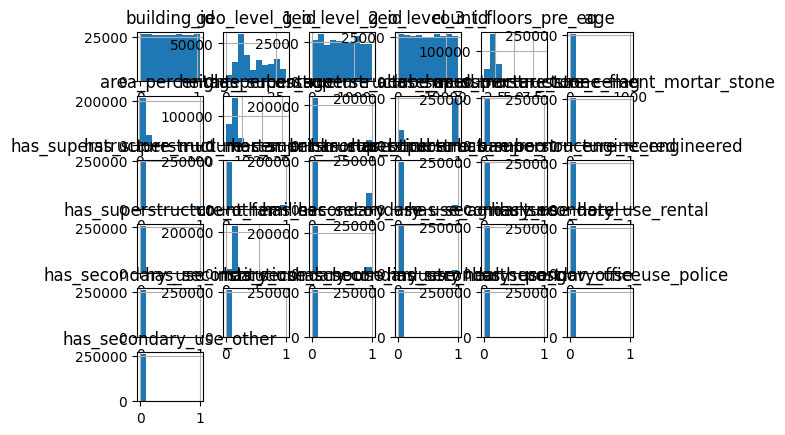

In [12]:
data.hist()

In [15]:
data.isnull().sum()

building_id                               0
geo_level_1_id                            0
geo_level_2_id                            0
geo_level_3_id                            0
count_floors_pre_eq                       0
age                                       0
area_percentage                           0
height_percentage                         0
land_surface_condition                    0
foundation_type                           0
roof_type                                 0
ground_floor_type                         0
other_floor_type                          0
position                                  0
plan_configuration                        0
has_superstructure_adobe_mud              0
has_superstructure_mud_mortar_stone       0
has_superstructure_stone_flag             0
has_superstructure_cement_mortar_stone    0
has_superstructure_mud_mortar_brick       0
has_superstructure_cement_mortar_brick    0
has_superstructure_timber                 0
has_superstructure_bamboo       

In [16]:
data.columns

Index(['building_id', 'geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id',
       'count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage',
       'land_surface_condition', 'foundation_type', 'roof_type',
       'ground_floor_type', 'other_floor_type', 'position',
       'plan_configuration', 'has_superstructure_adobe_mud',
       'has_superstructure_mud_mortar_stone', 'has_superstructure_stone_flag',
       'has_superstructure_cement_mortar_stone',
       'has_superstructure_mud_mortar_brick',
       'has_superstructure_cement_mortar_brick', 'has_superstructure_timber',
       'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered',
       'has_superstructure_rc_engineered', 'has_superstructure_other',
       'legal_ownership_status', 'count_families', 'has_secondary_use',
       'has_secondary_use_agriculture', 'has_secondary_use_hotel',
       'has_secondary_use_rental', 'has_secondary_use_institution',
       'has_secondary_use_school', 'has_secondary_use_i

In [17]:
columns_to_drop = data.columns[26::]
print(columns_to_drop)
data.drop(columns=columns_to_drop, inplace=True)

Index(['legal_ownership_status', 'count_families', 'has_secondary_use',
       'has_secondary_use_agriculture', 'has_secondary_use_hotel',
       'has_secondary_use_rental', 'has_secondary_use_institution',
       'has_secondary_use_school', 'has_secondary_use_industry',
       'has_secondary_use_health_post', 'has_secondary_use_gov_office',
       'has_secondary_use_use_police', 'has_secondary_use_other'],
      dtype='str')


In [29]:
a = pearsonr(data["geo_level_1_id"], data["geo_level_2_id"])
for column_a in data.columns[1:-1]:
    for column_b in data.columns[2::]:
        try:
            if pearsonr(data[column_a], data[column_b])[0]:
                print(f"correlation between {column_a} and {column_b} is {pearsonr(data[column_a], data[column_b])[0]}")
        except:
            print(f"correlation between {column_a} and {column_b}")

KeyboardInterrupt: 

In [ ]:
# import
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load data
y_train = pd.read_csv('data/train_labels.csv')
X_train = pd.read_csv('data/train_values.csv')
X_test = pd.read_csv('data/test_values.csv')

# explore
X_train.head()
# print(X_train.describe())
# plot
# X_test.hist()
import numpy as np

mask = np.eye(X_test.select_dtypes(include='number').corr().shape[0], dtype=bool)
sns.heatmap(X_test.select_dtypes(include='number').corr(), mask=mask, cmap='RdBu_r', vmin=-1, vmax=1)
plt.savefig('data/test.svg')
plt.show()
pass
